## This miniproject will show some experiment with MCMC and Linear Regression 

In [8]:
import pandas as pd 
import numpy as np
import scipy
import matplotlib.pyplot as plt 

### Part 1: Experiment when scaling a pdf function by a constant 

In [63]:
import copy 
# The code below implement MCMC with Metropolis-Hasting algorithm for the next state transition

def mcmc(initial_state, log_pdf_fn, proposed_fn, iters = 10000):
    state_list = [initial_state]
    while iters > 0:
        cur_state = state_list[-1] 
        proposed_state = proposed_fn(cur_state)
        log_diff = min(log_pdf_fn(proposed_state) - log_pdf_fn(cur_state), 0)
        next_state = proposed_state if (log_diff > np.log(np.random.uniform(0, 1))) else cur_state 
        state_list.append(copy.deepcopy(next_state))
        iters -= 1

    return state_list 

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_33123/194311265.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


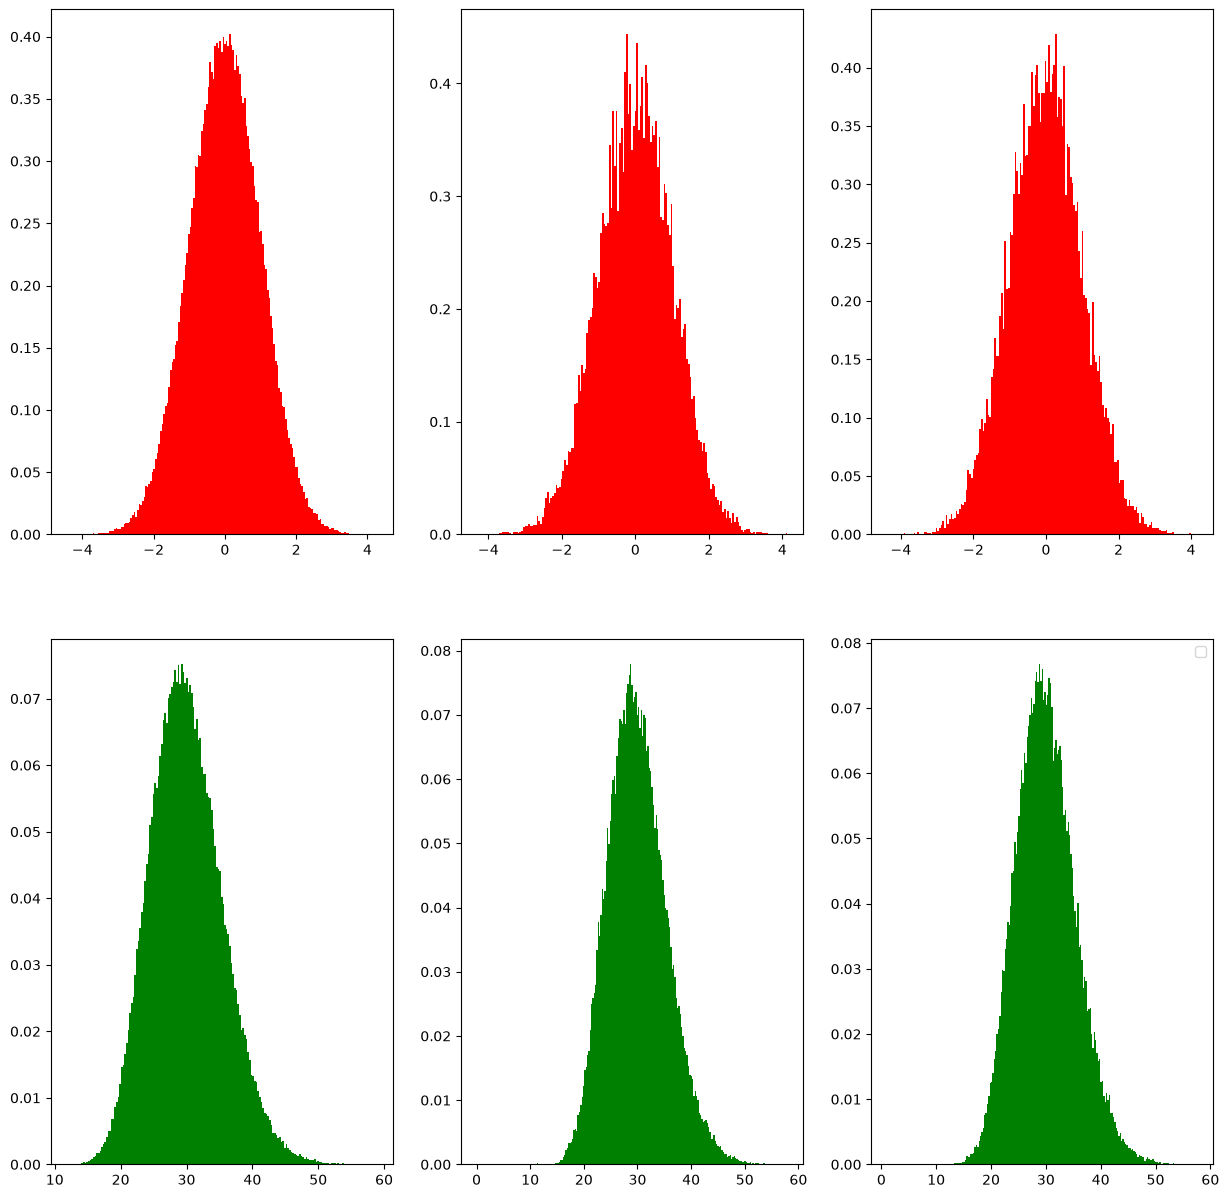

In [87]:
from functools import partial

distribs = [
    scipy.stats.norm(loc = 0, scale = 1), 
    scipy.stats.gamma(a = 30), 
] 

z0, z1, size, scale_lambda = 0, 1, 200000, 2 

def proposed_fn(z):
    return z + np.random.normal() * 10  

def scale_log_fn(fn, x): 
    return np.log(scale_lambda) + fn(x)

colors = ['red', 'green', 'blue']
fig, axes = plt.subplots(len(distribs), 3, squeeze=False, figsize = (15, 15))
for i in range(len(distribs)):
    axes[i, 0].hist(distribs[i].rvs(size = size), bins = 'auto', density = True, color = colors[i])
    axes[i, 1].hist(mcmc(z0, distribs[i].logpdf, proposed_fn, iters = size), bins = 'auto', density = True, color = colors[i]) 
    axes[i, 2].hist(mcmc(z1, partial(scale_log_fn, distribs[i].logpdf), proposed_fn, iters = size), bins = 'auto', density = True, color = colors[i]) 
    
plt.legend()
plt.show()

### Part 2: Tracking a position in 2D space 

In [ ]:
# unknown 
x_truth = 1, y_truth = 1 

radars = [
    (0, 0), 
    (10, 10), 
    (6, 3)
]